# Statistical Analysis

Goals: understand which features are redundant with each other  and which features are most related to Length of Stay (LOS).

## Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import spearmanr, mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("final.csv")

TARGET = "LOS"
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

print(f"Shape: {df.shape}")
print(f"LOS missing: {df[TARGET].isna().sum()} ({df[TARGET].isna().mean():.1%})")
print(f"\nLOS summary (days):")
display(df[TARGET].describe().to_frame().T.style.format("{:.2f}"))

num_features = 25


Shape: (62722, 217)
LOS missing: 1200 (1.9%)

LOS summary (days):


,count,mean,std,min,25%,50%,75%,max
LOS,61522.00,4.92,9.64,0.00,1.11,2.09,4.48,173.07


In [3]:
# Count categorical features in the dataset
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print(f"Categorical features: {len(categorical_cols)}")
print(categorical_cols)


Categorical features: 7
['GENDER', 'DOB', 'ADMISSION_TYPE', 'DIAGNOSIS', 'ADMITTIME', 'INTIME', 'END_FIRST_24H']


## LOS Distribution

It's important that we check on how out target looks first. LOS might have a long right tai: most patients stay a few days, a small number stay weeks.


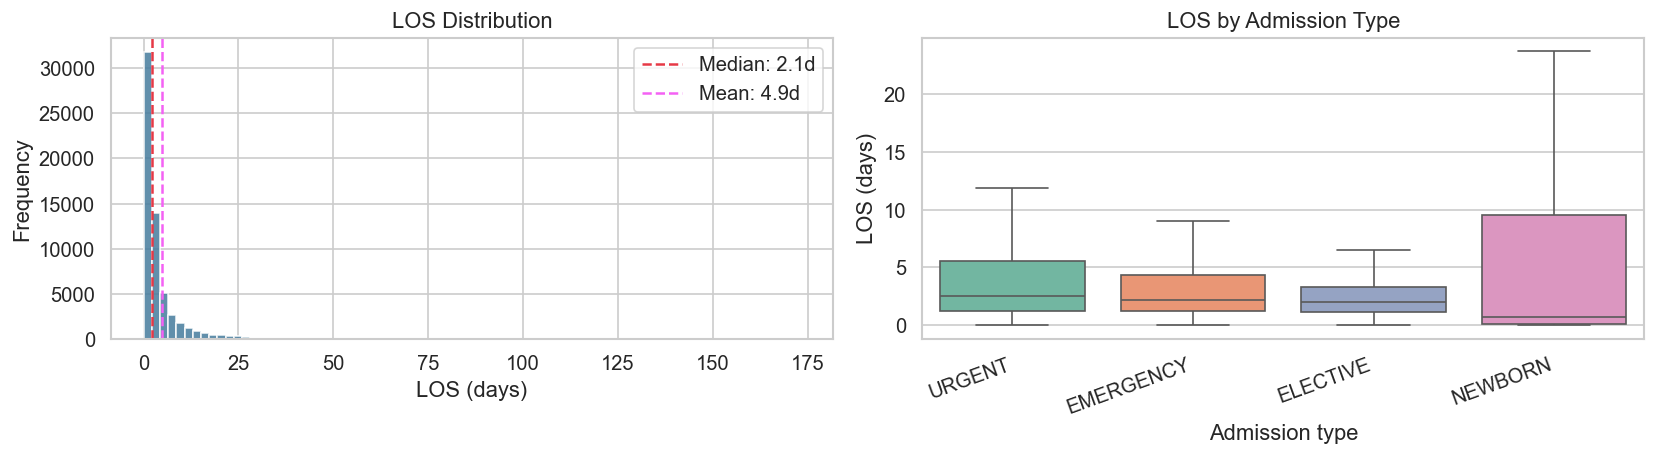

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

los = df[TARGET].dropna()

# Histogram
axes[0].hist(los, bins=80, color="#457b9d", edgecolor="white", alpha=0.85)
axes[0].axvline(los.median(), color="#e63946", linestyle="--",
                label=f"Median: {los.median():.1f}d")
axes[0].axvline(los.mean(),   color="#f461f4", linestyle="--",
                label=f"Mean: {los.mean():.1f}d")
axes[0].set_xlabel("LOS (days)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("LOS Distribution")
axes[0].legend()

# Bboxplot
if "ADMISSION_TYPE" in df.columns:
    order = (df.groupby("ADMISSION_TYPE")[TARGET]
               .median()
               .sort_values(ascending=False)
               .index)
    sns.boxplot(data=df, x="ADMISSION_TYPE", y=TARGET,
                order=order, palette="Set2",
                showfliers=False, ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
    axes[1].set_xlabel("Admission type")
    axes[1].set_ylabel("LOS (days)")
    axes[1].set_title("LOS by Admission Type")
else:
    axes[1].text(0.5, 0.5, "ADMISSION_TYPE not available",
                 ha="center", va="center", fontsize=11)
    axes[1].axis("off")

plt.tight_layout()
plt.show()


## Feature–LOS Association

### Numeric features -> Spearman ρ (rho)
Measures the strength of any monotonic (1-to-1) relationship with LOS (does not assume linearity or normality).  
- |ρ| > 0.3 is considered moderate in clinical data; |ρ| > 0.5 is strong.

### Categorical features -> Mann-Whitney / Kruskal-Wallis
Non-parametric tests that ask: is LOS different across the groups defined by this variable?
- Mann-Whitney: 2 groups. Kruskal-Wallis: ≥ 3 groups.

### Multiple-testing correction (Benjamini-Hochberg FDR)
Testing many features at once inflates false positives. BH-FDR controls the expected proportion of false discoveries to ≤ 5%.


Rho tells how strong the relationship is. p tells how confident we are that the relationship is real and not just noise/luck.

In [5]:
# spearman
exclude = {TARGET, "LOS_quartile"}

num_results = []
for col in df.select_dtypes(include="number").columns:
    if col in exclude:
        continue
    tmp = df[[col, TARGET]].dropna()
    if len(tmp) < 30:
        continue
    rho, p = spearmanr(tmp[col], tmp[TARGET])
    num_results.append({"feature": col, "rho": rho, "p_value": p})

num_df = pd.DataFrame(num_results).sort_values("p_value")

# bh-fdr
reject, p_adj, _, _ = multipletests(num_df["p_value"].values, method="fdr_bh")
num_df["p_adj"]       = p_adj
num_df["significant"] = reject
num_df["abs_rho"]     = num_df["rho"].abs()

# categorical
cat_results = []
exclude_cat = {"LOS_quartile"}
for col in df.select_dtypes(include=["object", "category", "bool"]).columns:
    if col in exclude_cat:
        continue
    tmp    = df[[col, TARGET]].dropna()
    groups = [g[TARGET].values for _, g in tmp.groupby(col) if len(g) >= 2]
    if len(groups) < 2:
        continue
    if len(groups) == 2:
        stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
        test    = "Mann-Whitney U"
    else:
        stat, p = kruskal(*groups)
        test    = "Kruskal-Wallis"
    cat_results.append({"feature": col, "test": test, "p_value": p, "n_groups": len(groups)})

cat_df = pd.DataFrame(cat_results).sort_values("p_value") if cat_results else pd.DataFrame()

if not cat_df.empty:
    rej_c, p_adj_c, _, _ = multipletests(cat_df["p_value"].values, method="fdr_bh")
    cat_df["p_adj"]       = p_adj_c
    cat_df["significant"] = rej_c

# summary
print(f"Numeric features tested:    {len(num_df)}")
print(f"  Significant (raw p<0.05): {(num_df['p_value'] < 0.05).sum()}")
print(f"  Significant (FDR<0.05):   {num_df['significant'].sum()}")

if not cat_df.empty:
    print(f"\nCategorical features tested:  {len(cat_df)}")
    print(f"  Significant (raw p<0.05): {(cat_df['p_value'] < 0.05).sum()}")
    print(f"  Significant (FDR<0.05):   {cat_df['significant'].sum()}")


Numeric features tested:    206
  Significant (raw p<0.05): 156
  Significant (FDR<0.05):   154

Categorical features tested:  5
  Significant (raw p<0.05): 4
  Significant (FDR<0.05):   4


In [6]:
# top numeric features by association with LOS
print("Top numeric features (FDR-significant, sorted by |ρ|):")
display(
    num_df[num_df["significant"]]
    .sort_values("abs_rho", ascending=False)
    .head(num_features) 
    [["feature", "rho", "p_adj"]]
    .style
    .format({"rho": "{:.3f}", "p_adj": "{:.2e}"})
    .background_gradient(subset=["rho"], cmap="RdBu_r", vmin=-1, vmax=1)
)


Top numeric features (FDR-significant, sorted by |ρ|):


,feature,rho,p_adj
166,vasopressin_sum,0.456,4.16e-31
155,midazolam_sum,0.407,6.31e-137
28,gcs_verbal_avg,-0.365,0.00e+00
46,gcs_total_max,-0.361,0.00e+00
27,gcs_total_avg,-0.355,0.00e+00
47,gcs_verbal_max,-0.353,0.00e+00
193,midazolam_count,0.324,1.56e-84
25,gcs_eye_avg,-0.315,0.00e+00
9,gcs_verbal_min,-0.298,0.00e+00
204,vasopressin_count,0.287,3.11e-12


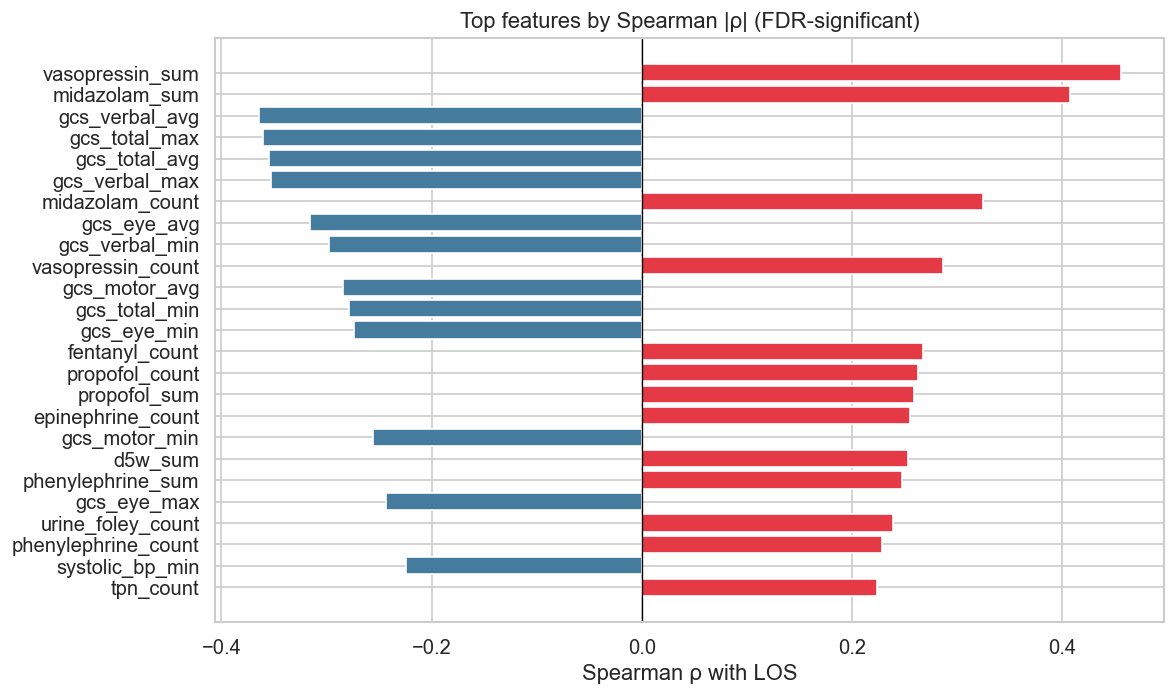


Significant categorical features (FDR):


,feature,test,n_groups,p_adj
2,ADMISSION_TYPE,Kruskal-Wallis,4,3.44e-247
3,DIAGNOSIS,Kruskal-Wallis,3348,1.58e-145
1,DOB,Kruskal-Wallis,14385,3.82e-32
4,ADMITTIME,Kruskal-Wallis,3521,1.32e-13


In [7]:
# bar chart with top features
top20 = (
    num_df[num_df["significant"]]
    .sort_values("abs_rho", ascending=False)
    .head(num_features) 
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e63946" if r >= 0 else "#457b9d" for r in top20["rho"]]
ax.barh(top20["feature"][::-1], top20["rho"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman ρ with LOS")
ax.set_title("Top features by Spearman |ρ| (FDR-significant)")
plt.tight_layout()
plt.show()

if not cat_df.empty and cat_df["significant"].any():
    print("\nSignificant categorical features (FDR):")
    display(
        cat_df[cat_df["significant"]]
        .sort_values("p_adj")
        [["feature", "test", "n_groups", "p_adj"]]
        .style.format({"p_adj": "{:.2e}"})
    )


## Mutual Information

Spearman only detects monotonic relationships. Mutual Information (MI) detects any*statistical dependency (U-shaped, threshold, non-linear).

The MI score has no absolute scale; what matters is the relative ranking between features.

* High MI, high ρ -> Strong monotonic relationship  
* High MI, low ρ -> Non-linear relationship (would be missed by Spearman alone )
* Low MI, high ρ -> Weak relationship overall 
* Low MI, low ρ -> Little relationship with LOS 


In [8]:
mi_feats = [
    f for f in num_df["feature"].tolist()
    if f in df.columns and f not in {TARGET}
]

X_mi = df[mi_feats].copy()
y_mi = df[TARGET].values

mask = ~np.isnan(y_mi)
X_mi = X_mi[mask]
y_mi = y_mi[mask]

imp = SimpleImputer(strategy="median")
X_mi_imp = imp.fit_transform(X_mi)

mi_scores = mutual_info_regression(X_mi_imp, y_mi, random_state=42)

mi_df = (
    pd.DataFrame({"feature": mi_feats, "MI": mi_scores})
    .sort_values("MI", ascending=False)
    .merge(num_df[["feature", "rho", "abs_rho", "p_adj", "significant"]], on="feature", how="left")
)

print("Top features by Mutual Information:")
display(
    mi_df.head(num_features)
    .style.format({"MI": "{:.4f}", "rho": "{:.3f}", "p_adj": "{:.2e}"})
    .background_gradient(subset=["MI"],      cmap="Greens")
    .background_gradient(subset=["abs_rho"], cmap="Blues")
)


Top features by Mutual Information:


,feature,MI,rho,abs_rho,p_adj,significant
0,gcs_verbal_avg,0.2611,-0.365,0.364603,0.00e+00,True
1,gcs_eye_avg,0.2583,-0.315,0.315388,0.00e+00,True
2,temperature_avg,0.2292,-0.063,0.062837,1.40e-50,True
3,temperature_max,0.2145,0.117,0.116669,1.25e-171,True
4,respiratory_rate_min,0.2128,-0.192,0.191583,0.00e+00,True
5,systolic_bp_avg,0.2107,-0.121,0.121441,5.10e-190,True
6,heart_rate_avg,0.1996,0.082,0.081711,2.30e-87,True
7,respiratory_rate_avg,0.1809,-0.009,0.009055,3.83e-02,True
8,systolic_bp_min,0.1788,-0.224,0.224161,0.00e+00,True
9,ph_blood_latest,0.1705,0.213,0.212613,0.00e+00,True


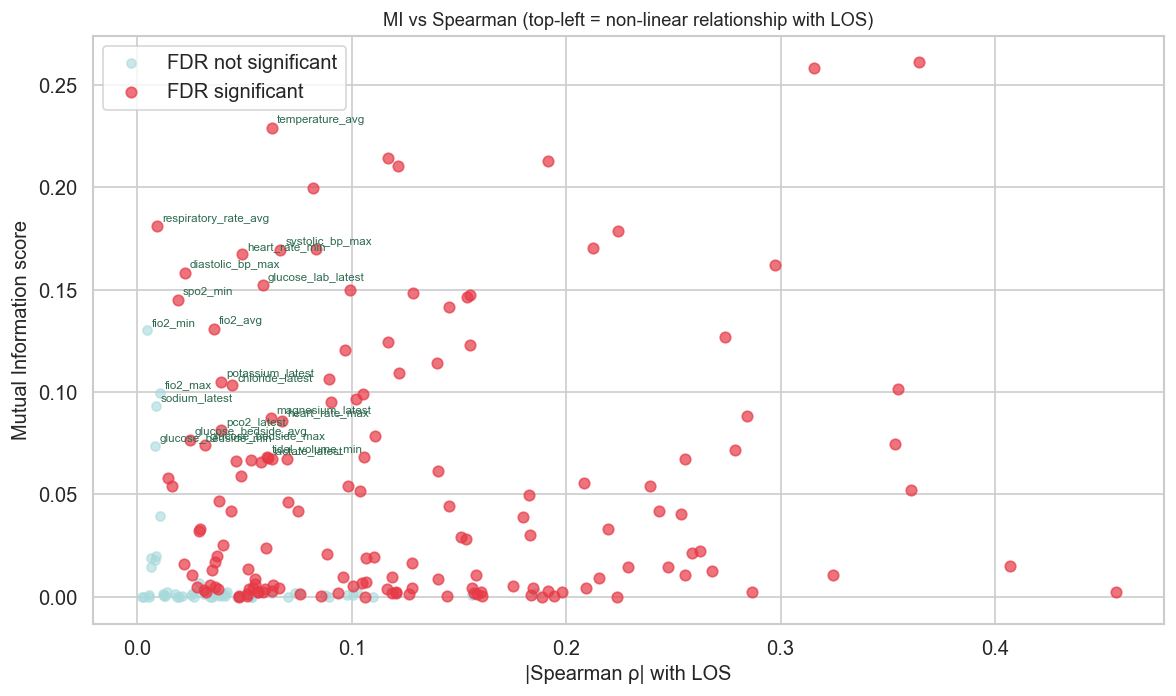

Potential non-linear features (high MI, low ρ):
             feature       MI  abs_rho
     temperature_avg 0.229178 0.062837
respiratory_rate_avg 0.180940 0.009055
     systolic_bp_max 0.169625 0.066549
      heart_rate_min 0.167302 0.048715
    diastolic_bp_max 0.158375 0.022138
  glucose_lab_latest 0.152093 0.058358
            spo2_min 0.145170 0.018742
            fio2_avg 0.131010 0.035519
            fio2_min 0.130222 0.004538
    potassium_latest 0.105103 0.039201
     chloride_latest 0.103247 0.044322
            fio2_max 0.099564 0.010517
       sodium_latest 0.093160 0.008613
    magnesium_latest 0.087148 0.062261
      heart_rate_max 0.085948 0.067336
         pco2_latest 0.081354 0.039185
 glucose_bedside_avg 0.076579 0.024338
 glucose_bedside_max 0.074212 0.031482
 glucose_bedside_min 0.073540 0.008039
    tidal_volume_min 0.068416 0.060236
      lactate_latest 0.067609 0.060916


In [9]:
# scatter
fig, ax = plt.subplots(figsize=(10, 6))

sig_m  = mi_df["significant"].fillna(False)
ax.scatter(mi_df.loc[~sig_m, "abs_rho"], mi_df.loc[~sig_m, "MI"],
           color="#a8dadc", alpha=0.6, s=30, label="FDR not significant")
ax.scatter(mi_df.loc[sig_m,  "abs_rho"], mi_df.loc[sig_m,  "MI"],
           color="#e63946",  alpha=0.7, s=40, label="FDR significant")

# Annotate high-MI low-ρ candidates 
nonlinear = mi_df[
    (mi_df["MI"]      > mi_df["MI"].quantile(0.75)) &
    (mi_df["abs_rho"] < mi_df["abs_rho"].quantile(0.5))
]
for _, row in nonlinear.iterrows():
    ax.annotate(row["feature"],
                (row["abs_rho"], row["MI"]),
                fontsize=7, xytext=(3, 3), textcoords="offset points",
                color="#2d6a4f")

ax.set_xlabel("|Spearman ρ| with LOS", fontsize=12)
ax.set_ylabel("Mutual Information score", fontsize=12)
ax.set_title("MI vs Spearman (top-left = non-linear relationship with LOS)", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

if not nonlinear.empty:
    print("Potential non-linear features (high MI, low ρ):")
    print(nonlinear[["feature", "MI", "abs_rho"]].to_string(index=False))


## Feature Redundancy

Here we look at between-feature correlations.
Two features with |ρ| > 0.7 between them carry largely the same information and one could be dropped.

We use all FDR-significant features with |ρ_LOS| > 0.05 as the candidate set.


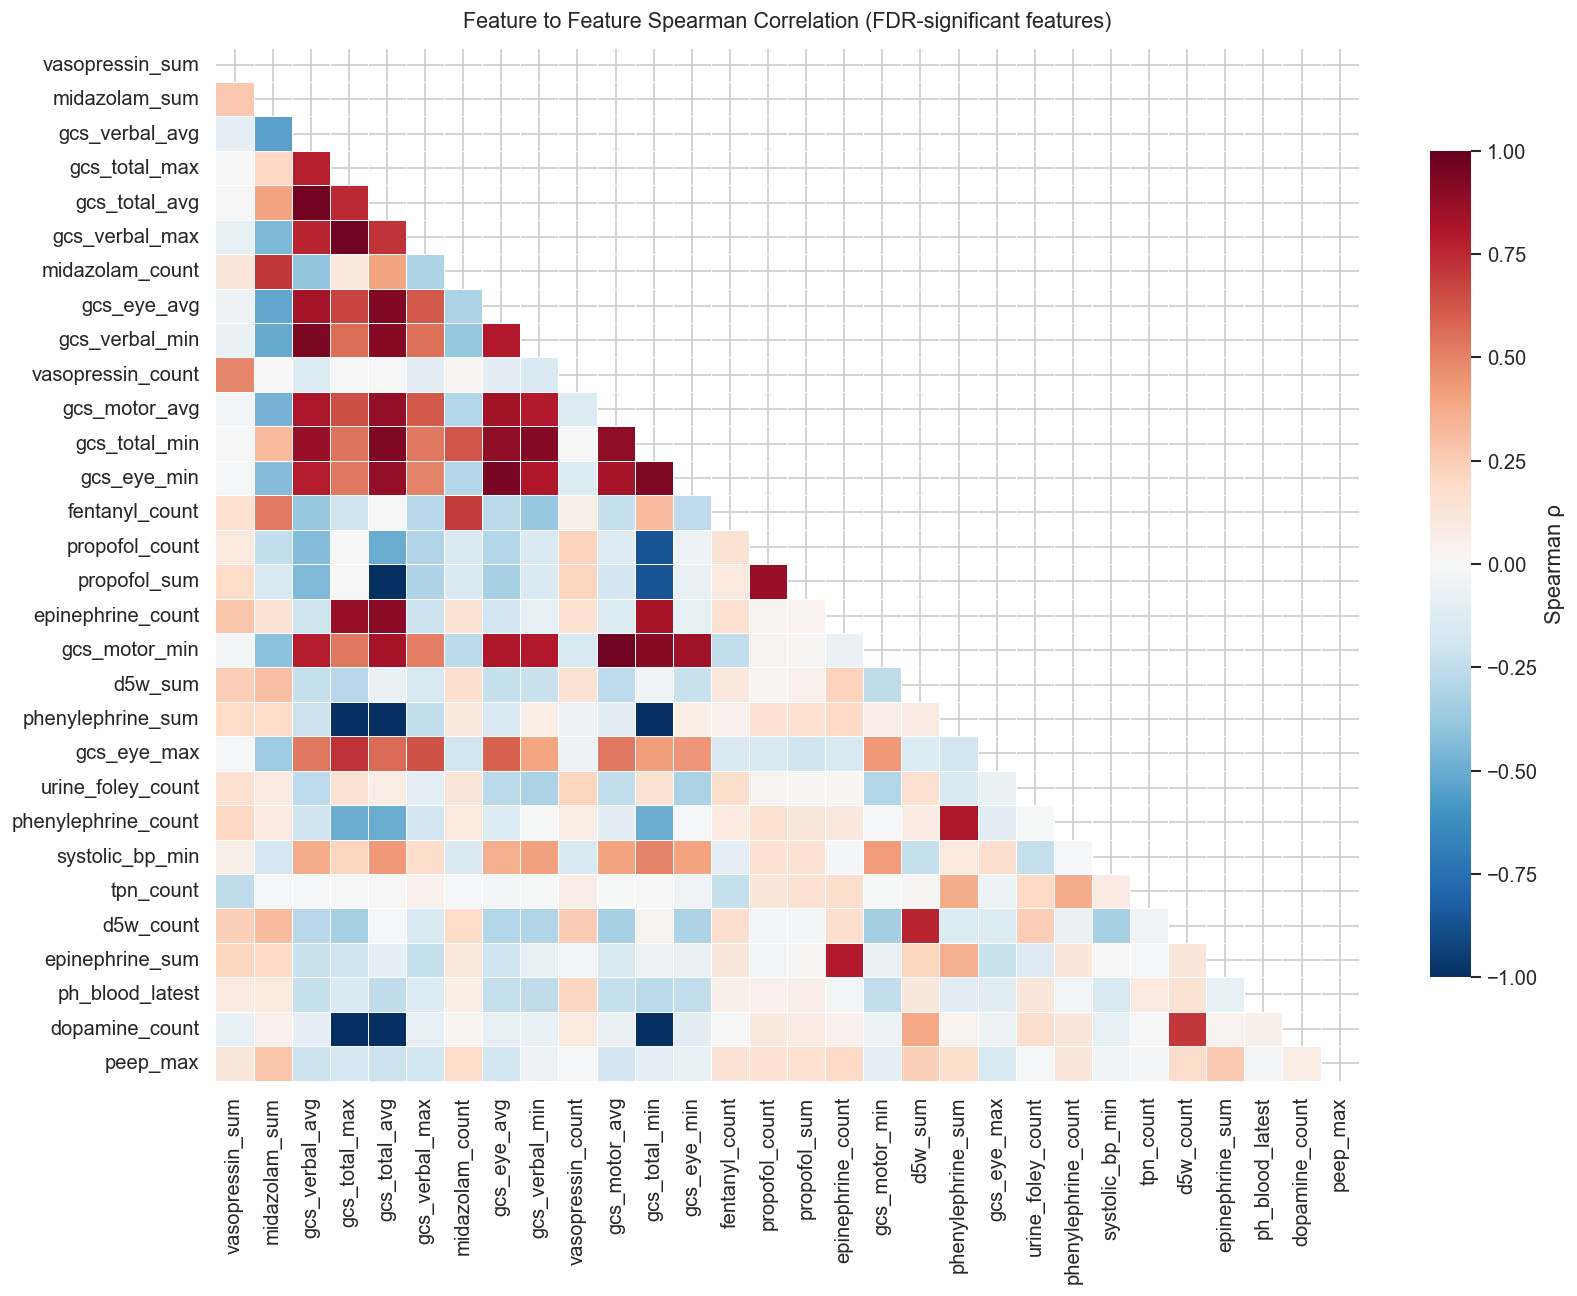

In [10]:
# Select features: FDR-significant and even weakly associated with LOS
redund_feats = (
    num_df[num_df["significant"] & (num_df["abs_rho"] > 0.05)]
    .sort_values("abs_rho", ascending=False)
    ["feature"]
    .head(30)
    .tolist()
)
redund_feats = [f for f in redund_feats if f in df.columns]

corr_mat = df[redund_feats].corr(method="spearman")

# Preencher NaN com 0 para garantir que todos os quadrados têm cor
corr_mat_filled = corr_mat.fillna(0)

# Heatmap — mostrar só o triângulo inferior (excluindo a diagonal)
mask_tri = np.triu(np.ones_like(corr_mat_filled, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_mat_filled, mask=mask_tri, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1,
    annot=len(redund_feats) <= 20,
    fmt=".2f", annot_kws={"size": 7},
    linewidths=0.3, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"}
)
ax.set_title("Feature to Feature Spearman Correlation (FDR-significant features)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [11]:
# High-correlation pairs (|ρ| > 0.7) — redundant candidates
high_pairs = []
cols = corr_mat.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_mat.iloc[i, j]
        if abs(r) > 0.7:
            # Which of the two is more related to LOS?
            rho_i = num_df.loc[num_df["feature"] == cols[i], "abs_rho"].values
            rho_j = num_df.loc[num_df["feature"] == cols[j], "abs_rho"].values
            rho_i = float(rho_i[0]) if len(rho_i) else 0
            rho_j = float(rho_j[0]) if len(rho_j) else 0
            keep   = cols[i] if rho_i >= rho_j else cols[j]
            drop   = cols[j] if rho_i >= rho_j else cols[i]
            high_pairs.append({
                "feature_A":        cols[i],
                "feature_B":        cols[j],
                "ρ_between":        round(r, 3),
                "|ρ_LOS| A":        round(rho_i, 3),
                "|ρ_LOS| B":        round(rho_j, 3),
                "keep (more LOS)":  keep,
                "drop (redundant)": drop,
            })

if high_pairs:
    pairs_df = pd.DataFrame(high_pairs).sort_values("ρ_between", key=abs, ascending=False)
    print(f"{len(high_pairs)} pairs with |ρ| > 0.7 (potential redundancy):")
    display(
        pairs_df.style
        .format({"ρ_between": "{:.3f}", "|ρ_LOS| A": "{:.3f}", "|ρ_LOS| B": "{:.3f}"})
        .background_gradient(subset=["ρ_between"], cmap="RdBu_r", vmin=-1, vmax=1)
    )
else:
    print("No pairs with |ρ| > 0.7 among the selected features.")


52 pairs with |ρ| > 0.7 (potential redundancy):


,feature_A,feature_B,ρ_between,|ρ_LOS| A,|ρ_LOS| B,keep (more LOS),drop (redundant)
13,gcs_total_max,phenylephrine_sum,-1.000,0.361,0.248,gcs_total_max,phenylephrine_sum
15,gcs_total_max,dopamine_count,-1.000,0.361,0.209,gcs_total_max,dopamine_count
25,gcs_total_avg,phenylephrine_sum,-1.000,0.355,0.248,gcs_total_avg,phenylephrine_sum
22,gcs_total_avg,propofol_sum,-1.000,0.355,0.259,gcs_total_avg,propofol_sum
45,gcs_total_min,dopamine_count,-1.000,0.279,0.209,gcs_total_min,dopamine_count
26,gcs_total_avg,dopamine_count,-1.000,0.355,0.209,gcs_total_avg,dopamine_count
44,gcs_total_min,phenylephrine_sum,-1.000,0.279,0.248,gcs_total_min,phenylephrine_sum
38,gcs_motor_avg,gcs_motor_min,0.971,0.284,0.255,gcs_motor_avg,gcs_motor_min
11,gcs_total_max,gcs_verbal_max,0.970,0.361,0.353,gcs_total_max,gcs_verbal_max
2,gcs_verbal_avg,gcs_total_avg,0.962,0.365,0.355,gcs_verbal_avg,gcs_total_avg


## Feature Ranking

Combine Spearman |ρ| and MI into a single summary table, ranked by average percentile across both methods.  
This highlights features that are consistently informative regardless of the method.


In [12]:
# Merge Spearman + MI; rank by average percentile
summary = (
    mi_df[["feature", "MI", "rho", "abs_rho", "p_adj", "significant"]]
    .copy()
    .rename(columns={"abs_rho": "|ρ_LOS|", "p_adj": "p_adj_FDR"})
)

summary["MI_pct"]  = summary["MI"].rank(pct=True)
summary["rho_pct"] = summary["|ρ_LOS|"].rank(pct=True)
summary["score"]   = (summary["MI_pct"] + summary["rho_pct"]) / 2

summary = summary.sort_values("score", ascending=False)

print("Top features:")
display(
    summary.head(num_features) 
    [["feature", "|ρ_LOS|", "rho", "MI", "p_adj_FDR", "significant", "score"]]
    .style
    .format({"|ρ_LOS|": "{:.3f}", "rho": "{:.3f}",
             "MI": "{:.4f}", "p_adj_FDR": "{:.2e}", "score": "{:.3f}"})
    .background_gradient(subset=["|ρ_LOS|"], cmap="Blues")
    .background_gradient(subset=["MI"],       cmap="Greens")
    .background_gradient(subset=["score"],    cmap="Purples")
)


Top features:


,feature,|ρ_LOS|,rho,MI,p_adj_FDR,significant,score
0,gcs_verbal_avg,0.365,-0.365,0.2611,0.00e+00,True,0.995
1,gcs_eye_avg,0.315,-0.315,0.2583,0.00e+00,True,0.981
13,gcs_verbal_min,0.298,-0.298,0.1622,0.00e+00,True,0.949
8,systolic_bp_min,0.224,-0.224,0.1788,0.00e+00,True,0.925
4,respiratory_rate_min,0.192,-0.192,0.2128,0.00e+00,True,0.913
9,ph_blood_latest,0.213,0.213,0.1705,0.00e+00,True,0.913
24,gcs_eye_min,0.274,-0.274,0.1271,0.00e+00,True,0.913
33,gcs_total_avg,0.355,-0.355,0.1015,0.00e+00,True,0.910
39,gcs_motor_avg,0.284,-0.284,0.0882,0.00e+00,True,0.881
45,gcs_verbal_max,0.353,-0.353,0.0745,0.00e+00,True,0.879
